## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>6 - Column Generation</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

---

## Exercise 6.1

The work [23] presents the column generation for the capacitated p-median problem. The compact Capacitated P-Median Problem (CPMP) is defined as:

$$
\begin{align}
\min \quad &
\sum_{i \in N} \sum_{j \in N} d_{ij} x_{ij}
\\[1ex]
\text{s.t.} \quad
& \sum_{j \in N} x_{jj} = p
\\[1ex]
& \sum_{j \in N} x_{ij} = r
&& \forall i \in N
\\[1ex]
& x_{ij} \le x_{jj}
&& \forall i, j \in N
\\[1ex]
& \sum_{i \in N} c_{i} x_{ij} \le C x_{jj}
&& \forall j \in N 
\\[1ex]
& x_{ij} \in \{0,1\}
&& \forall i, j \in N
\\[1ex]
\end{align}
$$

where:

- $𝑁$: set of clients and potential facility locations
- $𝑑_{𝑖𝑗}$: distance between client 𝑖 and facility 𝑗
- $𝑥_{𝑖𝑗}$: decision variables (assign client 𝑖 to facility 𝑗)
- $𝑝$: number of facilities to open
- $𝑐_𝑖$: demand of client 𝑖
- $𝐶$: capacity of each facility

[23] L. A. Lorena and E. L. Senne, “A column generation approach to capacitated p-median problems,” Computers & Operations Research, vol. 31, no. 6, pp. 863–876, 2004, doi: 10.1016/S0305-0548(03)00028-0.

### a) Implement the column generation method and solve the linear relaxation of the problem until convergence. Use the dataset [sjc_n=30_p=7_C=25.csv](data/sjc_n=30_p=7_C=25.csv) using 𝑝 = 7 and 𝐶 = 25.

--- Starting Column Generation ---

| Iteration | Reduced Cost | RMP Objective | Columns |
|-----------|--------------|---------------|---------|
|         1 |     -1195.58 |      5452.409 |    1521 |
|         2 |      -669.71 |      4492.844 |    1545 |
|         3 |      -595.48 |      3751.066 |    1564 |
|         4 |      -351.03 |      3629.761 |    1586 |
|         5 |      -224.31 |      3323.915 |    1602 |
|         6 |      -163.99 |      3127.170 |    1617 |
|         7 |      -174.30 |      3022.213 |    1628 |
|         8 |      -179.16 |      2907.673 |    1646 |
|         9 |       -76.07 |      2881.754 |    1650 |
|        10 |       -64.43 |      2881.754 |    1658 |
|        11 |       -15.88 |      2877.364 |    1663 |
|        12 |       -78.09 |      2877.364 |    1672 |
|        13 |       -47.12 |      2877.364 |    1673 |
|        14 |       -20.52 |      2877.364 |    1674 |

--- Column Generation Complete ---

No more profitable columns found. Optimal LP so

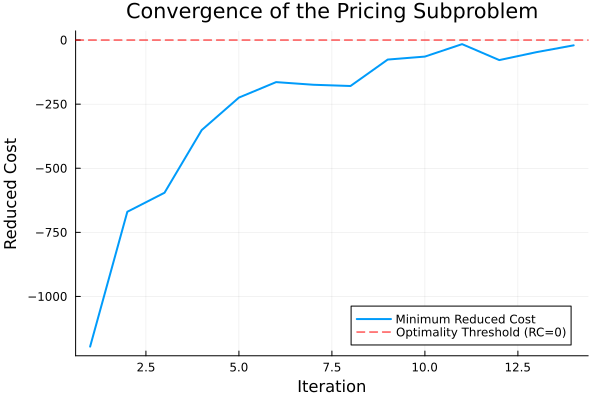

In [5]:
using JuMP       # Modeling language
using HiGHS      # Solver
using CSV        # For reading CSV files
using DataFrames # For handling data frames
using Distances  # For distance calculations
using Random     # For random number generation
using Printf     # For formatted printing

# Utility functions for plotting convergence
include("utils/cg_pmp-n_utils.jl")

# Structure to hold problem data
struct CPMPData
    n::Int64                     # Number of points
    p::Int64                     # Number of facilities to open
    C::Int64                     # Capacity of each facility
    coordinates::Matrix{Float64} # Coordinates of points
    distance::Matrix{Float64}    # Distance matrix between points
    demand::Vector{Int64}        # Demand at each point
    # Constructor
    function CPMPData(file_path::String; p::Int64=7, C::Int64=25)
        df = CSV.read(file_path, DataFrame)
        coordinates = Matrix{Float64}(df[:, [1, 2]])
        distance_matrix = pairwise(Haversine(), coordinates, dims=1)
        demand = Vector{Int64}(df[:, 3])
        new(nrow(df), p, C, coordinates, distance_matrix, demand)
    end
end

# Structure to hold column information
struct CPMPColumn
    cost::Float64
    median::Int64
    assignments::Vector{Bool}
end

# Structure to hold the solution of the RMP
struct CPMPSolution
    y::Vector{Float64}
    objective::Float64
    duals::Dict{String, Any}
end

# Optimized function to create initial columns
function cpmp_create_initial_columns(data::CPMPData, total::Int64)
    columns = Vector{CPMPColumn}(undef, total)
    for id in 1:total
        assignments = falses(data.n)
        current_capacity = 0
        while true
            for i in shuffle(1:data.n)
                if rand() > 0.5 && (current_capacity + data.demand[i] <= data.C)
                    assignments[i] = true
                    current_capacity += data.demand[i]
                end
            end
            if sum(assignments) > 0
                break
            end
        end
        # Find the median (facility) with minimum total assignment cost
        min_cost = Inf
        median = 1
        for i in 1:data.n
            if assignments[i] == 1
                cost = sum(assignments[j] * data.distance[i, j] for j in 1:data.n)
                if cost < min_cost
                    min_cost = cost
                    median = i
                end
            end
        end
        columns[id] = CPMPColumn(min_cost, median, assignments)
    end
    return columns
end

# Function to solve the Restricted Master Problem (RMP)
function cpmp_solve_restricted_master_problem(data::CPMPData, columns::Vector{CPMPColumn})
    # Number of clients, facilities and columns
    nC = nF = data.n
    ncols = length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, 0 <= y[1:ncols] <= 1)
    # Objective: Minimize the total cost of the selected columns
    @objective(model, Min, sum(y[i] * columns[i].cost for i in 1:ncols))
    # Constraint: Each client 'j' must be served by at least one selected column
    @constraint(model, covering_satisfaction[j=1:nC], sum(columns[i].assignments[j] * y[i] for i in 1:ncols) >= 1)
    # Constraint: Ensures that exactly 'p' columns are chosen
    @constraint(model, p_median_satisfaction, sum(y) == data.p)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results and return dual prices
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        y_values = JuMP.value.(y)
        objective = JuMP.objective_value(model)
        π = JuMP.dual.(covering_satisfaction)
        σ = JuMP.dual(p_median_satisfaction)
        duals = Dict("π" => π, "σ" => σ)
        return CPMPSolution(y_values, objective, duals)
    else
        error("RMP was not solved to optimality.")
    end
end

# Function to solve the Pricing Subproblem for each facility and generate new columns
function cpmp_solve_pricing_subproblem(data::CPMPData, columns::Vector{CPMPColumn}, rmp_solution::CPMPSolution; tolerance::Float64 = 1e-6)
    # Extract dual prices from the RMP solution
    π = rmp_solution.duals["π"]
    σ = rmp_solution.duals["σ"]
    # Number of clients and facilities
    nC = data.n
    nF = data.n
    # Initialize variables to track the best column found
    min_reduced_cost = typemax(Float64)
    # Now we solve 1-knapsack problem for each facility
    for f in 1:nF
        # Create model
        model = JuMP.Model(HiGHS.Optimizer)
        # Silent mode (solver output is not printed)
        JuMP.set_silent(model)
        # Unidimensional variable: does client 'c' go to facility 'f'?
        @variable(model, x[1:nC], Bin)
        # Objective: Minimize the reduced cost of the column
        @objective(model, Min, sum((data.distance[c, f] - π[c]) * x[c] for c in 1:nC) - σ)
        # Capacity constraint for facility 'f'
        @constraint(model, sum(data.demand[c] * x[c] for c in 1:nC) <= data.C)
        # Solve the model
        JuMP.optimize!(model)
        # Check the results and calculate the reduced cost
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            reduced_cost = JuMP.objective_value(model)
            # If the reduced cost is strictly negative, the column is advantageous
            if reduced_cost < -tolerance
                # Extract the clients assigned to this facility
                assignments = JuMP.value.(x) .> 0.5
                
                # Check if the assignments are valid (not all zeros)
                is_invalid = sum(assignments) == 0

                # Check if is duplicated
                is_duplicate = any(c -> c.assignments == assignments, columns)

                # Prevent creating columns with no assignments and avoid duplicates
                if !is_invalid && !is_duplicate
                    min_reduced_cost = min(min_reduced_cost, reduced_cost)
                    # Calculate the actual cost of the column (sum of distances of active clients)
                    cost = sum(data.distance[c, f] for c in 1:nC if assignments[c])
                    # Add the new column to the list of columns
                    push!(columns, CPMPColumn(cost, f, assignments))
                end
            end
        end    
    end
    return min_reduced_cost
end

# Function to solve the CPMP using column generation
function cpmp_solve_gc(data::CPMPData; initial_columns_total::Int64 = 20, iterations::Int64 = 100, tolerance::Float64 = 1e-6, print_feedback_interval::Int64 = 10)

    println("--- Starting Column Generation ---\n")

    println("| Iteration | Reduced Cost | RMP Objective | Columns |")
    println("|-----------|--------------|---------------|---------|")

    # DataFrame to store results of each iteration
    results = DataFrame(Iteration = Int[], ReducedCost = Float64[], RMPObjective = Float64[], Columns = Int[])

    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # --- 1. Create initial columns ---
    columns = cpmp_create_initial_columns(data, initial_columns_total)

    best_solution = nothing

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
        
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        rmp_solution = cpmp_solve_restricted_master_problem(data, columns)

        # --- 4. Solve the Pricing Subproblem ---
        reduced_cost = cpmp_solve_pricing_subproblem(data, columns, rmp_solution, tolerance = tolerance)

        # --- 5. Check if a new pattern was found ---
        if reduced_cost < -tolerance
            if iteration == 1 || iteration % print_feedback_interval == 0
                @printf("| %9d | %12.2f | %13.3f | %7d |\n", 
                        iteration, 
                        reduced_cost, 
                        rmp_solution.objective,
                        length(columns))
            end
            push!(reduced_cost_history, reduced_cost)
            best_solution = deepcopy(rmp_solution)
            # Add results to DataFrame
            push!(results, (iteration, reduced_cost, rmp_solution.objective, length(columns)))
        else
            println("\n--- Column Generation Complete ---\n")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        end
    end
    # --- 6. Generate reduced cost Plot ---
    cpmp_plot_reduced_costs(reduced_cost_history)
    return best_solution, columns, results
end

# Set random seed for reproducibility
Random.seed!(42)

# Read data and compute distance matrix
data = CPMPData("data/sjc_n=30_p=7_C=25.csv"; p = 7, C = 25)

# Example usage
relaxed_solution, columns, results = cpmp_solve_gc(data, initial_columns_total = 1500, iterations = 1500, tolerance = 1e-6, print_feedback_interval = 1);

println("\nFinal RMP Objective: ", relaxed_solution.objective)

### b) Based on the columns generated in item (a), solve the Restricted Master Integer Problem (RMIP) by imposing integrality constraints on the master problem variables to obtain an integer solution.

In [2]:
# Function to solve the Restricted Master Integer Problem (RMIP)
function cpmp_solve_restricted_master_integer_problem(data::CPMPData, columns::Vector{CPMPColumn})
    # Number of clients, facilities and columns
    nC = nF = data.n
    ncols = length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, y[1:ncols], Bin)
    # Objective: Minimize the total cost of the selected columns
    @objective(model, Min, sum(y[i] * columns[i].cost for i in 1:ncols))
    # Constraint: Each client 'j' must be served by at least one selected column
    @constraint(model, covering_satisfaction[j=1:nC], sum(columns[i].assignments[j] * y[i] for i in 1:ncols) >= 1)
    # Constraint: Ensures that exactly 'p' columns are chosen
    @constraint(model, p_median_satisfaction, sum(y) == data.p)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results and return dual prices
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        # Extract the objective value
        objective = JuMP.objective_value(model)
        println("RMIP solution found with objective value: ", objective)
        solution = Dict()
        # Extract the selected columns
        selected_columns = columns[JuMP.value.(y) .> 0.5]        
        # Order selected columns by their median index for better readability
        selected_columns = sort!(selected_columns, by = col -> col.median)
        println("Selected columns (facilities opened): ", [col.median for col in selected_columns])
        # For each selected column, print the assigned clients
        for col in selected_columns
            assigned_clients = [j for j in 1:nC if col.assignments[j]]
            println("Facility $(col.median) serves clients: ", assigned_clients)
            solution[col.median] = assigned_clients
        end
        # Plot the solution
        cpmp_plot_solution(data.coordinates, solution, data.p)
    else
        error("RMP was not solved to optimality.")
    end
end

# Example usage of the integer version of the RMP
cpmp_solve_restricted_master_integer_problem(data, columns)

RMIP solution found with objective value: 2947.040874259389
Selected columns (facilities opened): [2, 5, 6, 12, 18, 25, 26]
Facility 2 serves clients: [2, 13, 17, 24, 28, 29]
Facility 5 serves clients: [5, 15, 23]
Facility 6 serves clients: [1, 6, 14, 20]
Facility 12 serves clients: [8, 12, 16]
Facility 18 serves clients: [4, 18, 19, 22, 27]
Facility 25 serves clients: [3, 7, 9, 11, 25]
Facility 26 serves clients: [10, 21, 26, 30]


Python: <folium.folium.Map object at 0x7fe3835e6cf0>

### c) Solve the original integer formulation of the Capacitated P-Median Problem and compare the results obtained in items (a) and (b). Discuss:

* The gap between the linear relaxation and the optimal integer solution;
* The gap between the RMIP solution and the optimal integer solution;
* The quality of the generated column set.

In [3]:
# Function to solve the CPMP using Integer Linear Programming (ILP)
function cpmp_solve_ilp(data::CPMPData)
    nC = nF = data.n
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[c in 1:nC,f in 1:nF], Bin)
    # Objective: Minimize the total cost of the selected columns
    @objective(model, Min, sum(x[c, f] * data.distance[c, f] for c in 1:nC, f in 1:nF))
    # Exactly 'p' facilities must be opened
    @constraint(model, sum(x[f, f] for f in 1:nF) == data.p)
    # Each client must be assigned to exactly one facility
    @constraint(model, [c in 1:nC], sum(x[c, f] for f in 1:nF) == 1)
    # A client can only be assigned to an open facility (if x[c, f] = 1, then x[f, f] must be 1)
    @constraint(model, [c in 1:nC, f in 1:nF], x[c, f] <= x[f, f])
    # Each facility has a capacity constraint
    @constraint(model, [f in 1:nF], sum(data.demand[c] * x[c, f] for c in 1:nC) <= data.C * x[f, f])
    # Solve the model
    JuMP.optimize!(model)
    # Check the results    
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        objective = JuMP.objective_value(model)
        println("Optimal solution found with objective value: ", objective)
        x_values = JuMP.value.(x)
        solution = Dict()
        medians = [f for f in 1:nF if x_values[f, f] > 0.5]
        println("Optimal medians (facilities opened): ", sort!(medians))
        for median in medians
            assigned_clients = [c for c in 1:nC if x_values[c, median] > 0.5]
            println("Facility $median serves clients: ", assigned_clients)
            solution[median] = assigned_clients
        end
        # Plot the solution
        cpmp_plot_solution(data.coordinates, solution, data.p)
    else
        error("No optimal solution found")
    end
end

# Example usage of the ILP approach
cpmp_solve_ilp(data)

Optimal solution found with objective value: 2898.4216409686173
Optimal medians (facilities opened): [2, 6, 12, 15, 25, 26, 27]
Facility 2 serves clients: [2, 13, 17, 24, 28, 29]
Facility 6 serves clients: [1, 6, 14, 20]
Facility 12 serves clients: [8, 12, 16]
Facility 15 serves clients: [5, 15, 23]
Facility 25 serves clients: [3, 7, 9, 11, 25]
Facility 26 serves clients: [10, 21, 26, 30]
Facility 27 serves clients: [4, 18, 19, 22, 27]


Python: <folium.folium.Map object at 0x7fe38139c7d0>

#### Discussion

The following table presents the objective values obtained by the Restricted Master Problem (RMP), the Restricted Master Integer Problem (RMIP), and the Integer Linear Programming (ILP) model, together with the corresponding integrality gap.

<div align="center">

| Technique | Objective | Gap (%) |
| --------- | --------: | ------: |
| RMP       |   2835.50 |    2.17 |
| RMIP      |   2898.42 |    0.00 |
| ILP       |   2898.42 |     N/A |

</div>

The column generation approach produced a final RMP objective value of 2835.50, providing a lower bound with an integrality gap of 2.17% relative to the optimal integer solution. The columns generated during the column generation process were sufficient for the RMIP to recover the global optimum, yielding the same objective value as the original ILP model (2898.42) without requiring additional branching procedures.

---

## Exercise 6.2

The work [57] presents a column generation approach to the modularity max-
imization problem in complex networks.

[57] D. Aloise, S. Cafieri, G. Caporossi, P. Hansen, S. Perron, and L. Liberti,
“Column generation algorithms for exact modularity maximization in net-
works,” Physical Review E, vol. 82, no. 4, p. 46112, 2010, doi: 10.1103/
PhysRevE.82.046112.

### a) Implement the Column Generation described by the authors, and test it in the dataset [karate.csv](data/karate.csv).

--- Starting Column Generation ---

| Iteration | Reduced Cost | RMP Objective | Columns |
|-----------|--------------|---------------|---------|
|         1 |        0.160 |         0.074 |     535 |
|        50 |        0.028 |         0.420 |     582 |
|       100 |        0.007 |         0.420 |     629 |
|       150 |        0.003 |         0.420 |     667 |

--- Column Generation Complete ---

No more profitable columns found. Optimal LP solution reached.

Final RMP Objective: 0.41978961209730414


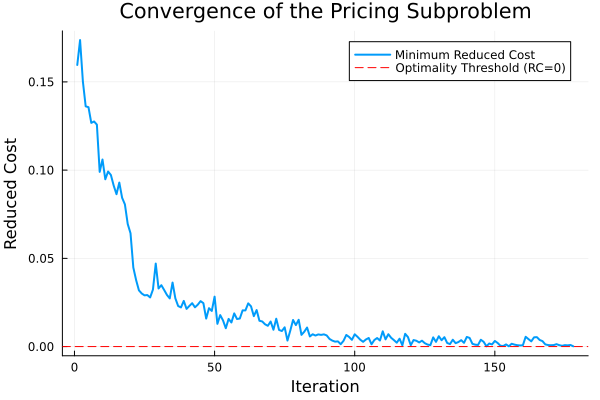

In [1]:
using JuMP       # Modeling language
using HiGHS      # Solver
using DataFrames # For handling data frames
using Graphs     # For graph data structures
using Random     # For random number generation
using Printf     # For formatted printing

# Utility functions for plotting convergence
include("utils/cg_cpp_utils.jl")

# Structure to hold problem data
struct CPPData
    graph::Graphs.SimpleGraph
    Q::Matrix{Float64}
    # Constructor
    function CPPData(file_path::String)
        graph = Graphs.loadgraph(file_path)
        n, m = nv(graph), ne(graph)
        # Create modularity matrix Q
        C1 = 1.0 / (2 * m)
        C2 = 1.0 / (4 * m^2)
        Q = zeros(Float64,n,n)
        d = Graphs.degree(graph)
        for u in 1:n
            for v in 1:n
                Q[u,v] = Graphs.has_edge(graph, u, v) * C1 - (d[u] * d[v]) * C2
            end
        end
        return new(graph, Q)
    end
end

# Structure to hold column information
struct CPPColumn
    cost::Float64
    assignments::Vector{Bool}
end

# Structure to hold the solution of the RMP
struct CPPSolution
    y::Vector{Float64}
    objective::Float64
    duals::Dict{String, Any}
end

# Function to create initial columns for the column generation process
function cpp_create_initial_columns(data::CPPData, total::Int)
    n = nv(data.graph)
    columns = CPPColumn[]
    seen = Set{BitVector}()
    while length(columns) < total
        assignments = BitVector(rand(Bool, n))
        # Prevent creating columns with no assignments
        if !any(assignments)
            continue
        end
        # Prevent creating duplicate columns
        if assignments in seen
            continue
        end
        push!(seen, copy(assignments))
        cost = sum(
            data.Q[i,j] * assignments[i] * assignments[j]
            for i in 1:n, j in 1:n
        )
        push!(columns, CPPColumn(cost, assignments))
    end
    # Add singleton assignments for each vertex to ensure feasibility
    for v in 1:n
        assignments = falses(n)
        assignments[v] = true
        cost = data.Q[v,v]
        push!(columns, CPPColumn(cost, assignments))
    end
    return columns
end

# Function to solve the restricted master problem
function cpp_solve_restricted_master_problem(data::CPPData, columns::Vector{CPPColumn})
    n = nv(data.graph)
    n_cols = length(columns) 
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, 0 <= y[1:n_cols] <= 1)
    # Objective: Maximize modularity
    @objective(model, Max, sum(columns[c].cost * y[c] for c in 1:n_cols))
    # Constraints
    @constraint(model, partition_satisfaction[j=1:n], sum(columns[i].assignments[j] * y[i] for i in 1:n_cols) == 1)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results and return dual prices
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        y_values = JuMP.value.(y)
        objective = JuMP.objective_value(model)
        π = JuMP.dual.(partition_satisfaction)
        duals = Dict("π" => π)
        return CPPSolution(y_values, objective, duals)
    else
        error("RMP was not solved to optimality.")
    end
end

# Function to solve the pricing subproblem
function cpp_solve_pricing_subproblem(data::CPPData, columns::Vector{CPPColumn}, rmp_solution::CPPSolution; tolerance::Float64 = 1e-6)
    # Number of vertices in the graph
    n = nv(data.graph)
    # Extract dual prices from the RMP solution
    π = rmp_solution.duals["π"]
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, y[i=1:n], Bin)
    @variable(model, z[i=1:n, j=i+1:n], Bin)
    # Linearization: z[i,j] = y[i] * y[j]
    @constraint(model, [i=1:n, j=i+1:n], z[i,j] <= y[i])
    @constraint(model, [i=1:n, j=i+1:n], z[i,j] <= y[j])
    @constraint(model, [i=1:n, j=i+1:n], z[i,j] >= y[i] + y[j] - 1)
    # Objective
    objective = AffExpr()
    for i in 1:n
        # Diagonal values Qii * xi
        JuMP.add_to_expression!(objective, data.Q[i,i], y[i])
        # Off-diagonal terms
        for j in i+1:n
            JuMP.add_to_expression!(objective,
                                    2.0 * data.Q[i,j],
                                    z[i,j])
        end
        # Duals
        JuMP.add_to_expression!(objective,
                                π[i],
                                y[i])
    end
    @objective(model, Max, objective)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        # Extract the solution
        reduced_cost = JuMP.objective_value(model)
        if reduced_cost > tolerance
            # Extract vertices assigned to this column
            assignments = JuMP.value.(y) .> 0.5
            # Check if the assignments are valid (not all zeros)
            is_invalid = sum(assignments) == 0
            # Check if is duplicated
            is_duplicate = any(c -> c.assignments == assignments, columns)
            # Prevent creating columns with no assignments and avoid duplicates
            if !is_invalid && !is_duplicate
                # Calculate the cost of the new column
                cost = 0.0
                for i in 1:n
                    for j in 1:n
                        if assignments[i] && assignments[j]
                            cost += data.Q[i,j]
                        end
                    end
                end
                # Create the new column
                new_column = CPPColumn(cost, assignments)
                # Add the new column to the list of columns
                push!(columns, new_column)
            end
        end
        return reduced_cost
    else
        error("Pricing subproblem was not solved to optimality.")
    end
end

# Function to solve the CPP using column generation
function cpp_solve_gc(data::CPPData; initial_columns_total::Int64 = 20, iterations::Int64 = 100, tolerance::Float64 = 1e-6, print_feedback_interval::Int64 = 10)

    println("--- Starting Column Generation ---\n")

    println("| Iteration | Reduced Cost | RMP Objective | Columns |")
    println("|-----------|--------------|---------------|---------|")

    # DataFrame to store results of each iteration
    results = DataFrame(Iteration = Int[], ReducedCost = Float64[], RMPObjective = Float64[], Columns = Int[])

    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # --- 1. Create initial columns ---
    columns = cpp_create_initial_columns(data, initial_columns_total)
    # columns = cpp_create_initial_columns(data)

    # Store best solution found
    best_solution = nothing

    # Dual Stabilization (Smoothing)
    # π_prev = zeros(nv(data.graph))
    π_prev = 0.1 .* rand(nv(data.graph))
    α = 0.3 # Smoothing factor (0.3 to 0.5 is usually optimal)

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
        
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        rmp_solution = cpp_solve_restricted_master_problem(data, columns)

        # Stabilize the duals before feeding them to the pricing subproblem
        if iteration > 1
            rmp_solution.duals["π"] = α * rmp_solution.duals["π"] + (1 - α) * π_prev
        end
        π_prev = copy(rmp_solution.duals["π"])

        # --- 4. Solve the Pricing Subproblem ---
        reduced_cost = cpp_solve_pricing_subproblem(data, columns, rmp_solution, tolerance = tolerance)

        # --- 5. Check if a new pattern was found ---
        if reduced_cost > tolerance
            if iteration == 1 || iteration % print_feedback_interval == 0
                @printf("| %9d | %12.3f | %13.3f | %7d |\n", 
                        iteration, 
                        reduced_cost, 
                        rmp_solution.objective,
                        length(columns))
            end
            push!(reduced_cost_history, reduced_cost)
            best_solution = deepcopy(rmp_solution)
            # Add results to DataFrame
            push!(results, (iteration, reduced_cost, rmp_solution.objective, length(columns)))
        else
            println("\n--- Column Generation Complete ---\n")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        end
    end
    # --- 6. Generate reduced cost Plot ---
    cpp_plot_reduced_costs(reduced_cost_history)
    return best_solution, columns, results
end

# Set random seed for reproducibility
Random.seed!(42)

# Read data and compute modularity matrix
data = CPPData("data/karate.csv")

# Example usage
relaxed_solution, columns, results = cpp_solve_gc(data, initial_columns_total = 500, iterations = 200, tolerance = 1e-4, print_feedback_interval = 50);

println("\nFinal RMP Objective: ", relaxed_solution.objective)

### b) Based on the columns generated in item (a), solve the Restricted Master Integer Problem (RMIP) by imposing integrality constraints on the master problem variables to obtain an integer solution.

RMIP solution found with objective value: 0.41978961209730414
Community 1: [9, 10, 15, 16, 19, 21, 23, 27, 30, 31, 33, 34]
Community 2: [5, 6, 7, 11, 17]
Community 3: [24, 25, 26, 28, 29, 32]
Community 4: [1, 2, 3, 4, 8, 12, 13, 14, 18, 20, 22]


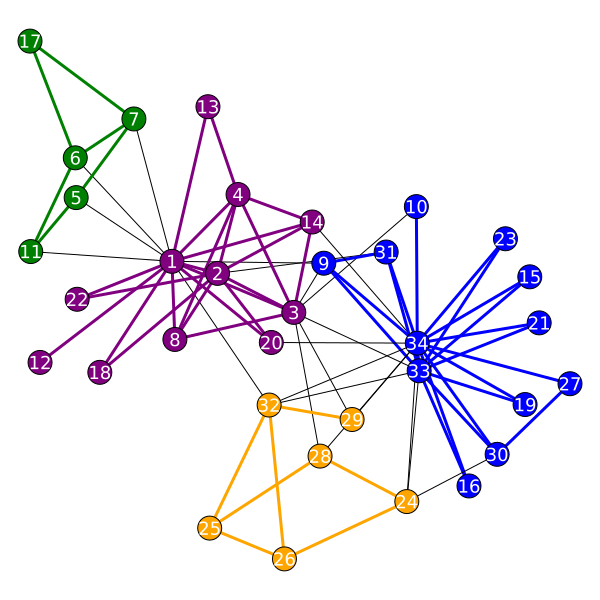

In [5]:
# Function to solve the Restricted Master Integer Problem (RMIP)
function cpp_solve_restricted_master_integer_problem(data::CPPData, columns::Vector{CPPColumn})
    n = nv(data.graph)
    n_cols = length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, y[1:n_cols], Bin)
    # Objective: Maximize modularity
    @objective(model, Max, sum(columns[c].cost * y[c] for c in 1:n_cols))
    # Constraints
    @constraint(model, [j=1:n], sum(columns[i].assignments[j] * y[i] for i in 1:n_cols) == 1)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results and return dual prices
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        objective = JuMP.objective_value(model)
        println("RMIP solution found with objective value: ", objective)
        solution = zeros(Int64,n)
        selected_columns = columns[JuMP.value.(y) .> 0.5]
        for (idx, col) in enumerate(selected_columns)
            assigned_vertices = [j for j in 1:n if col.assignments[j]]
            println("Community $(idx): ", assigned_vertices)
            solution[assigned_vertices] .= idx
        end
        # Plot the solution
        cpp_plot_solution(data.graph, solution)
    else
        error("RMP was not solved to optimality.")
    end
end

# Example usage of the integer version of the RMP
cpp_solve_restricted_master_integer_problem(data, columns)

### c) Solve the original integer formulation of the Clique Partitioning Problem and compare the results obtained in items (a) and (b). Discuss:

* The gap between the linear relaxation and the optimal integer solution;
* The gap between the RMIP solution and the optimal integer solution;
* The quality of the generated column set.

Optimal solution found with objective value: 0.41978961209730403
Community 1: 1 2 3 4 8 12 13 14 18 20 22 
Community 2: 5 6 7 11 17 
Community 3: 9 10 15 16 19 21 23 27 30 31 33 34 
Community 4: 24 25 26 28 29 32 


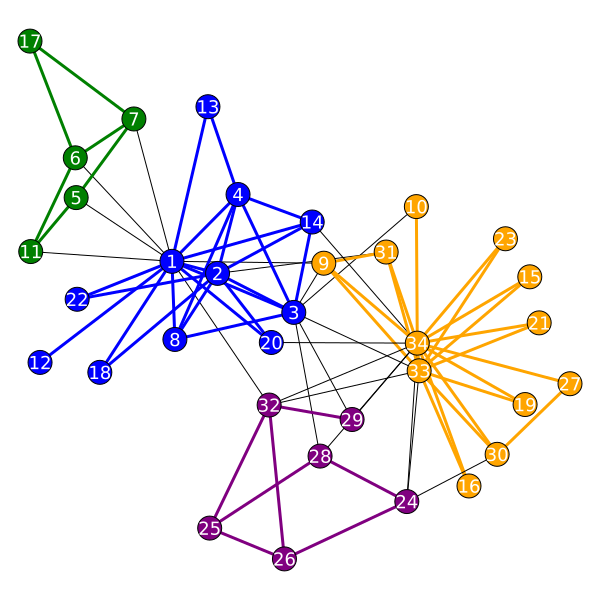

In [6]:
# Function to solve the CPP using Integer Linear Programming (ILP)
function cpp_solve_ilp(data::CPPData)
    # Get number of vertices and edges
    n = Graphs.nv(data.graph)
    m = Graphs.ne(data.graph)
    # Auxiliary variables to simplify notation
    V = 1:n
    # Modularity matrix Q
    Q = zeros(n,n)
    d = Graphs.degree(data.graph)
    for u in V
        for v in V
            a_ij = Graphs.has_edge(data.graph, u, v) ? 1 : 0
            Q[u,v] = a_ij/(2*m) - (d[u] * d[v]) / (4*m^2)
        end
    end
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define the decision variables
    @variable(model, x[u in V, v in V], Bin)
    # Objective: maximize the weight of the selected edges
    @objective(model, Max, sum(Q[u,v] * x[u,v] for u in V for v in V))
    # Transitive Constraints: ensure that the selected edges form a valid partition
    for u in V
        for v in V
            for w in V
                @constraint(model,  x[u,v] + x[v,w] - x[u,w] <= 1)
                @constraint(model,  x[u,v] - x[v,w] + x[u,w] <= 1)
                @constraint(model, -x[u,v] + x[v,w] + x[u,w] <= 1)
            end
        end
    end
    # Run the solver
    JuMP.optimize!(model)
    # Get the objective (Modularity)
    modularity = JuMP.objective_value(model)
    println("Optimal solution found with objective value: ", modularity)
    # Extract the optimal partition
    partition = zeros(Int64, n)
    partition_id = 1
    for u in V
        # If vertex u is not yet assigned to a partition
        if partition[u] == 0
            print("Community $partition_id: ")
            for v in V
                # If vertex v is in the same partition as u
                if JuMP.value(x[u,v]) > 0.5
                    # Assign both u and v to the same partition
                    partition[v] = partition_id
                    print("$v ")
                end
            end
            print("\n")
            partition_id += 1
        end
    end
    # Plot the solution
    cpp_plot_solution(data.graph, partition)
end

# Example usage of the ILP approach
cpp_solve_ilp(data)

#### Discussion

The following table presents the objective values obtained by the Restricted Master Problem (RMP), the Restricted Master Integer Problem (RMIP), and the Integer Linear Programming (ILP) model, together with the corresponding integrality gap.

<div align="center">

| Technique | Objective | Gap (%) |
| --------- | --------: | ------: |
| RMP       |   0.42 |    0.00 |
| RMIP      |   0.42 |    0.00 |
| ILP       |   0.42 |     N/A   |

</div>

The column generation approach produced a final RMP objective value of 0.42. Since the RMIP and the original ILP model achieved the same objective value (0.42), the integrality gap is 0.00%. This indicates that the linear relaxation provided by the RMP was already integral for this instance, and the set of columns generated during the column generation process was sufficient to recover the optimal integer solution. Consequently, the RMIP matched the ILP optimum without requiring any additional branching procedures.

---

## Exercise 6.3

The work [58] presents a column generation approach to the Graph Coloring
Problem (see also the work [59]).

[58] A. Mehrotra and M. A. Trick, “A column generation approach for graph
coloring,” INFORMS Journal on Computing, vol. 8, no. 4, pp. 344–354, 1996,
doi: 10.1287/ijoc.8.4.344.

[59] G. Ribeiro Filho and L. A. N. Lorena, “Constructive genetic algorithm and
column generation: an application to graph coloring,” in Proceedings of the
APORS 2000 The Fifth Conference of the Association of Asian Pacific Operations
Research Societies, 2000.

### a) Implement the column generation described by the authors, and test it with the following graph: [tutte_graph.csv](data/tutte_graph.csv)

![Tutte.](images/Chapter6-exercise3.png)

--- Starting Column Generation ---

| Iteration | Reduced Cost | RMP Objective | Columns |
|-----------|--------------|---------------|---------|
|         1 |      -18.000 |        46.000 |      47 |
|        50 |       -0.984 |         3.165 |      96 |
|       100 |       -0.465 |         2.760 |     146 |
|       150 |       -0.159 |         2.639 |     196 |
|       200 |       -0.083 |         2.553 |     246 |
|       250 |       -0.055 |         2.508 |     296 |

--- Column Generation Complete ---

No more profitable columns found. Optimal LP solution reached.

Final RMP Objective: 2.5005387931034484


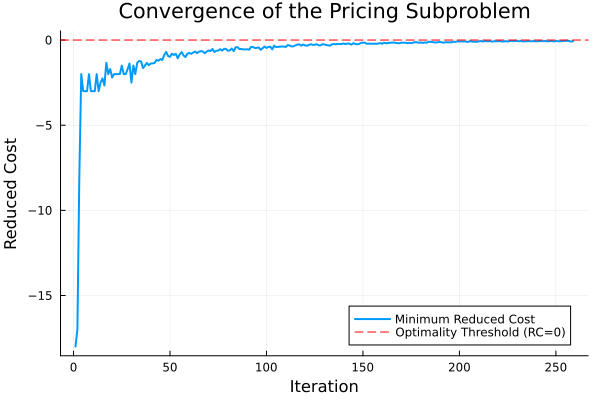

In [2]:
using JuMP       # Modeling language
using HiGHS      # Solver
using DataFrames # For handling data frames
using Graphs     # For graph data structures
using Printf     # For formatted printing

# Utility functions for plotting convergence
include("utils/cg_gcp_utils.jl")

# Structure to hold the solution of the RMP
struct GCPSolution
    selected_columns::Vector{Float64}
    objective::Float64
    duals::Dict{String, Any}
end

# Function to create initial columns for the column generation process
function gcp_create_initial_columns(graph::Graphs.Graph)
    # Each vertex is an independent set
    n = nv(graph)
    columns = Vector{BitVector}(undef, n)
    for i in 1:n
        independent_set = falses(n)
        independent_set[i] = true
        columns[i] = independent_set
    end
    return columns
end

# Function to solve the restricted master problem
function gcp_solve_restricted_master_problem(graph::Graphs.Graph, columns::Vector{BitVector})
    V = 1:nv(graph)
    C = 1:length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables (independent set)
    @variable(model, 0 <= y[c in C] <= 1)
    # Objective: Minimize total colors used
    @objective(model, Min, sum(y))
    # Constraints: Each vertex must be covered by at least one selected independent set
    @constraint(model, cover[v in V], sum(columns[c][v] * y[c] for c in C) >= 1)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results and return dual prices
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        selected_columns = JuMP.value.(y)
        objective = JuMP.objective_value(model)
        π = JuMP.dual.(cover)
        duals = Dict("π" => π)
        return GCPSolution(selected_columns, 
                           objective, 
                           duals)
    else
        error("RMP was not solved to optimality.")
    end
end

# Function to solve the pricing subproblem
function gcp_solve_pricing_subproblem(graph::Graphs.Graph, columns::Vector{BitVector}, rmp_solution::GCPSolution; tolerance::Float64 = 1e-6)
    V = 1:nv(graph)
    π = rmp_solution.duals["π"]
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[v in V], Bin)
    # Objective: Maximize the dual weights collected
    @objective(model, Max, sum(π[v] * x[v] for v in V))
    # Adjacency constraint: adjacent vertices cannot both be selected
    for e in Graphs.edges(graph)
        @constraint(model, x[e.src] + x[e.dst] <= 1)
    end
    # Solve the model
    JuMP.optimize!(model)
    # Check the results
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        reduced_cost = 1.0 - JuMP.objective_value(model)
        # If the reduced cost is negative, we have found a new column to add
        if reduced_cost < -tolerance
            # Extract vertices assigned to this column
            independent_set = JuMP.value.(x) .> 0.5

            # Check if the assignments are valid (not all zeros)
            is_invalid = sum(independent_set) == 0

            # Check if is duplicated
            is_duplicate = any(c -> c == independent_set, columns)

            # Prevent creating columns with no assignments or duplicates
            if !is_invalid && !is_duplicate
                push!(columns, independent_set)
            end
        end
        return reduced_cost
    else
        error("Pricing subproblem was not solved to optimality.")
    end
end

# Function to solve the GCP using column generation
function gcp_solve_gc(graph::Graphs.Graph; iterations::Int64 = 100, tolerance::Float64 = 1e-6, print_feedback_interval::Int64 = 10)
    
    println("--- Starting Column Generation ---\n")

    println("| Iteration | Reduced Cost | RMP Objective | Columns |")
    println("|-----------|--------------|---------------|---------|")

    # DataFrame to store results of each iteration
    results = DataFrame(Iteration = Int[], ReducedCost = Float64[], RMPObjective = Float64[], Columns = Int[])

    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # --- 1. Create initial columns ---
    columns = gcp_create_initial_columns(graph)

    # Store best solution found
    best_solution = nothing

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        rmp_solution = gcp_solve_restricted_master_problem(graph, columns)

        # --- 4. Solve the Pricing Subproblem ---
        reduced_cost = gcp_solve_pricing_subproblem(graph, columns, rmp_solution; tolerance = tolerance)

        # --- 5. Check if a new pattern was found ---
        if reduced_cost < -tolerance
            if iteration == 1 || iteration % print_feedback_interval == 0
                @printf("| %9d | %12.3f | %13.3f | %7d |\n", 
                        iteration, 
                        reduced_cost, 
                        rmp_solution.objective,
                        length(columns))
            end
            push!(reduced_cost_history, reduced_cost)
            best_solution = deepcopy(rmp_solution)
            # Add results to DataFrame
            push!(results, (iteration, reduced_cost, rmp_solution.objective, length(columns)))
        else
            println("\n--- Column Generation Complete ---\n")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        end
    end
    # --- 6. Generate reduced cost Plot ---
    gcp_plot_reduced_costs(reduced_cost_history)
    return best_solution, columns, results
end

# Example usage
graph = Graphs.loadgraph("data/tutte_graph.csv")

# Run the column generation algorithm for GCP
relaxed_solution, columns, results = gcp_solve_gc(graph, iterations = 500, tolerance = 1e-3, print_feedback_interval = 50);

println("\nFinal RMP Objective: ", relaxed_solution.objective)

### b) Based on the columns generated in item (a), solve the Restricted Master Integer Problem (RMIP) by imposing integrality constraints on the master problem variables to obtain an integer solution.

RMIP solution found with objective value: 2.9999999999999867
Color 1: [2, 3, 4, 10, 13, 15, 16, 18, 22, 26, 28, 30, 33, 34, 37, 39, 42, 45, 46]
Color 2: [1, 5, 7, 9, 14, 17, 19, 20, 22, 25, 27, 29, 31, 36, 38, 40, 41, 43]
Color 3: [2, 4, 6, 8, 11, 12, 14, 17, 21, 23, 24, 29, 32, 34, 35, 37, 44, 46]


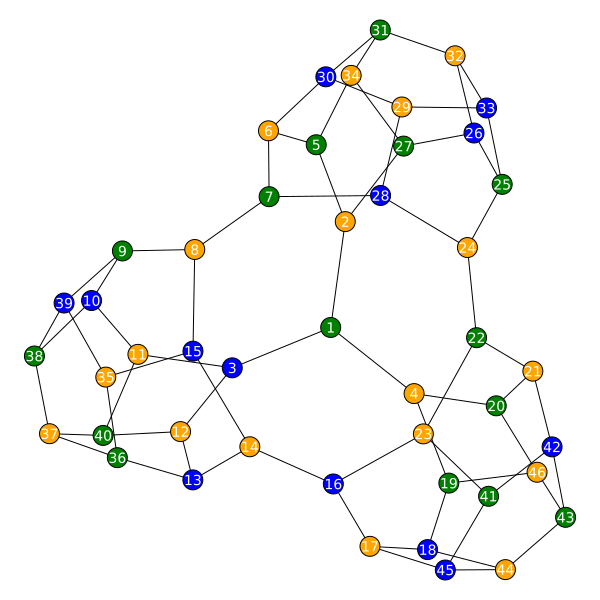

In [8]:
# Function to solve the Restricted Master Integer Problem (RMIP)
function gcp_solve_restricted_master_integer_problem(graph::Graphs.SimpleGraph, columns::Vector{BitVector})
    V = 1:nv(graph)
    C = 1:length(columns)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables (independent set)
    @variable(model, y[c in C], Bin)
    # Objective: Minimize total colors used
    @objective(model, Min, sum(y))
    # Constraints: Each vertex must be covered by at least one selected independent set
    @constraint(model, cover[v in V], sum(columns[c][v] * y[c] for c in C) >= 1)
    # Solve the model
    JuMP.optimize!(model)
    # Check the results and return dual prices
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        objective = JuMP.objective_value(model)
        println("RMIP solution found with objective value: ", objective)
        solution = zeros(Int, length(V))
        selected_columns = [c for c in C if JuMP.value(y[c]) > 0.5]
        for (idx, col) in enumerate(selected_columns)
            vertices = findall(columns[col])
            println("Color $(idx): ", vertices)
            solution[vertices] .= idx
        end
        gcp_plot_solution(graph, solution)
    else
        error("RMP was not solved to optimality.")
    end
end

# Example usage of the integer version of the RMP
gcp_solve_restricted_master_integer_problem(graph, columns)

### c) Solve the original integer formulation of the Graph Coloring Problem and compare the results obtained in items (a) and (b). Discuss:

* The gap between the linear relaxation and the optimal integer solution;
* The gap between the RMIP solution and the optimal integer solution;
* The quality of the generated column set.

Optimal solution found with objective value: 3
Color 1: [7, 9, 16, 29, 31, 36, 40, 42, 44]
Color 2: [2, 3, 4, 6, 10, 13, 15, 18, 21, 23, 24, 26, 33, 34, 37, 39, 45, 46]
Color 3: [1, 5, 8, 11, 12, 14, 17, 19, 20, 22, 25, 27, 28, 30, 32, 35, 38, 41, 43]


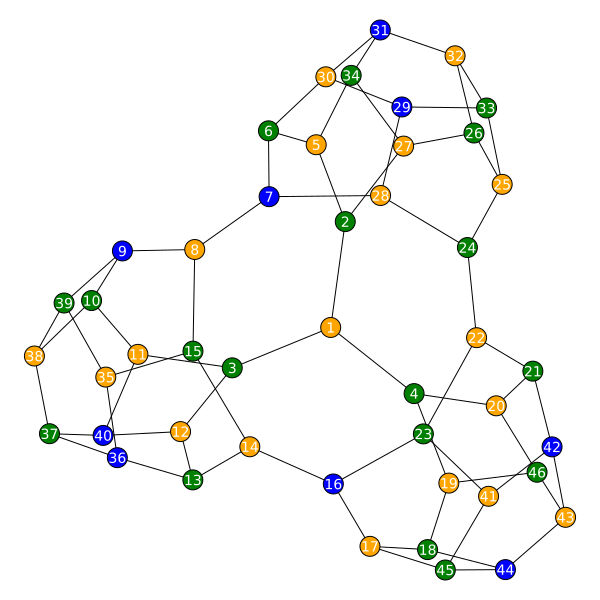

In [9]:
# Function to solve the GCP using Integer Linear Programming (ILP)
function gcp_solve_ilp(graph::Graphs.SimpleGraph)
    # Range of vertices
    N = 1:Graphs.nv(graph)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define the decision variables
    @variable(model, x[u in N, c in N], Bin)
    @variable(model, y[c in N], Bin)
    # Objective function: minimize the total of selected colors
    @objective(model, Min, sum(y))
    # Each vertex must be assigned to exactly one color
    @constraint(model, [u in N], sum(x[u, c] for c in N) == 1)
    # If a vertex uses color c, then color c is active
    @constraint(model, [u in N, c in N], x[u, c] <= y[c])
    # No two adjacent vertices share the same color
    for e in Graphs.edges(graph)
        u, v = e.src, e.dst
        for c in N
            @constraint(model, x[u, c] + x[v, c] <= 1)
        end
    end
    # Run the solver
    JuMP.optimize!(model)
    # Check the results
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        # Get the objective (Chromatic number)
        objective = Int(round(JuMP.objective_value(model)))
        println("Optimal solution found with objective value: $objective")
        # Extract the optimal color assignments
        x_opt = JuMP.value.(x)
        y_opt = JuMP.value.(y)
        solution = zeros(Int, length(N))
        # Print the color assignments
        selected_colors = [c for c in N if y_opt[c] > 0.5]
        for (id, pos) in enumerate(selected_colors)
            vertices = [v for v in N if x_opt[v, pos] > 0.5]
            println("Color $id: $vertices")
            solution[vertices] .= id
        end
        # Plot the graph with the assigned colors
        gcp_plot_solution(graph, solution)
    else
        error("Model was not solved to optimality.")
    end
end

# Example usage of the ILP approach
gcp_solve_ilp(graph)

#### Discussion

The following table presents the objective values obtained by the Restricted Master Problem (RMP), the Restricted Master Integer Problem (RMIP), and the Integer Linear Programming (ILP) model, together with the corresponding integrality gap.

<div align="center">

| Technique | Objective | Gap (%) |
| --------- | --------: | ------: |
| RMP       |   2.5 |    16.66 |
| RMIP      |   3 |    0.00 |
| ILP       |   3 |     N/A   |

</div>

The column generation approach produced a final RMP objective value of 2.5, providing a lower bound with an integrality gap of 16.66% relative to the optimal integer solution. Since the RMIP and the original ILP model achieved the same objective value (3), the integrality gap is 0.00%. This indicates that the linear relaxation provided by the RMP was not integral for this instance, but the set of columns generated during the column generation process was sufficient to recover the optimal integer solution. Consequently, the RMIP matched the ILP optimum without requiring any additional branching procedures.